In [ ]:
pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [18]:
df = pd.read_csv("/content/medical_insurance.csv")

df.drop(['region'], axis = 1, inplace = True)

for col in df.columns:
  if df[col].dtype == "object":
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

if df.isnull().sum().sum() > 0: # Check if there are any missing values at all
    imputer = SimpleImputer(strategy="most_frequent")

    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
    df = df_imputed

df.drop_duplicates(inplace = True)

df.dropna(inplace = True)

y = df['charges']
x = df.drop(['charges'], axis = 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

print(f"""

Data shapes after preprocessing:

df.shape : {df.shape}
x.shape : {x.shape}
y.shape : {y.shape}
x_train.shape : {x_train.shape}
x_test.shape : {x_test.shape}
y_train.shape : {y_train.shape}
y_test.shape : {y_test.shape}
""")



Data shapes after preprocessing:

df.shape : (1337, 6)
x.shape : (1337, 5)
y.shape : (1337,)
x_train.shape : (1069, 5)
x_test.shape : (268, 5)
y_train.shape : (1069,)
y_test.shape : (268,)



In [20]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

xgb_model = XGBRegressor(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,
    objective='reg:squarederror' # Objective for regression
)

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"""
Mean Absolute Error : {mae:.4f}
R-squared : {r2:.4f} """)


Mean Absolute Error : 3125.0514
R-squared : 0.8621 


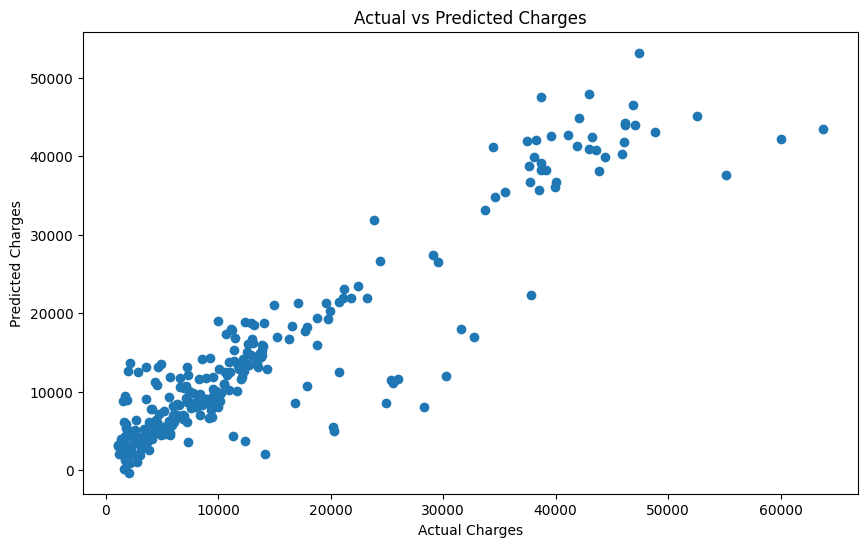

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

In [24]:
import joblib
if joblib.dump(xgb_model, 'product_recommnedation_system.pkl'):
  print("model saved")

model saved
